# SHAP Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import shap
import pickle
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path('..').resolve()))

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from src.data.preprocessing import prepare_data, prepare_lstm_data
from src.models.mlp import MLP
from src.models.rnn import GRUModel
from src.utils.paths import setup_plotting, ensure_dirs, PROCESSED_DIR, RESULTS_DIR, PROJECT_ROOT


setup_plotting()
ensure_dirs()

np.random.seed(42)
torch.manual_seed(42)

def create_spider_plot(data_dict, feature_labels, title, filename):
    """
    Creates a spider plot (radar chart).
    
    data_dict: dict of {model_name: [values]}
    feature_labels: list of feature names for axes
    title: chart title
    filename: save path
    """
    num_vars = len(feature_labels)
    
    # Split the circle into even parts and save the angles
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    
    # The plot is circular, so we need to "complete the loop"
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Draw one axe per variable + add labels
    plt.xticks(angles[:-1], feature_labels, size=10)
    
    # Draw ylabels
    ax.set_rlabel_position(0)
    
    # colors for models
    colors = {
        'Random Forest': '#2ecc71',
        'ElasticNet': '#9b59b6',
        'CatBoost': '#f1c40f',
        'MLP': '#3498db',
        'GRU': '#e74c3c'
    }
    
    for model_name, values in data_dict.items():
        # Complete the loop
        vals = values.copy()
        vals += vals[:1]
        
        ax.plot(angles, vals, color=colors.get(model_name, None), linewidth=2, linestyle='solid', label=model_name)
        ax.fill(angles, vals, color=colors.get(model_name, None), alpha=0.1)
    
    plt.title(title, size=16, color='black', y=1.1, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import shap
import pickle
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path('..').resolve()))

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from src.data.preprocessing import prepare_data, prepare_lstm_data
from src.models.mlp import MLP
from src.models.rnn import GRUModel
from src.utils.paths import setup_plotting, ensure_dirs, PROCESSED_DIR, RESULTS_DIR, PROJECT_ROOT


setup_plotting()
ensure_dirs()

np.random.seed(42)
torch.manual_seed(42)

def create_spider_plot(data_dict, feature_labels, title, filename):
    """
    Creates a spider plot (radar chart).
    
    data_dict: dict of {model_name: [values]}
    feature_labels: list of feature names for axes
    title: chart title
    filename: save path
    """
    num_vars = len(feature_labels)
    
    # Split the circle into even parts and save the angles
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    
    # The plot is circular, so we need to "complete the loop"
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Draw one axe per variable + add labels
    plt.xticks(angles[:-1], feature_labels, size=10)
    
    # Draw ylabels
    ax.set_rlabel_position(0)
    
    # colors for models
    colors = {
        'Random Forest': '#2ecc71',
        'ElasticNet': '#9b59b6',
        'CatBoost': '#f1c40f',
        'MLP': '#3498db',
        'GRU': '#e74c3c'
    }
    
    for model_name, values in data_dict.items():
        # Complete the loop
        vals = values.copy()
        vals += vals[:1]
        
        ax.plot(angles, vals, color=colors.get(model_name, None), linewidth=2, linestyle='solid', label=model_name)
        ax.fill(angles, vals, color=colors.get(model_name, None), alpha=0.1)
    
    plt.title(title, size=16, color='black', y=1.1, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

/home/bendavison/PycharmProjects/msc_dissertation/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Processing Dataset B

Dataset B: 79 samples, 199 features

Dataset B:
  Samples: 79
  Common features: 97
  Temporal shape: (79, 2, 97) (samples, timesteps, features)


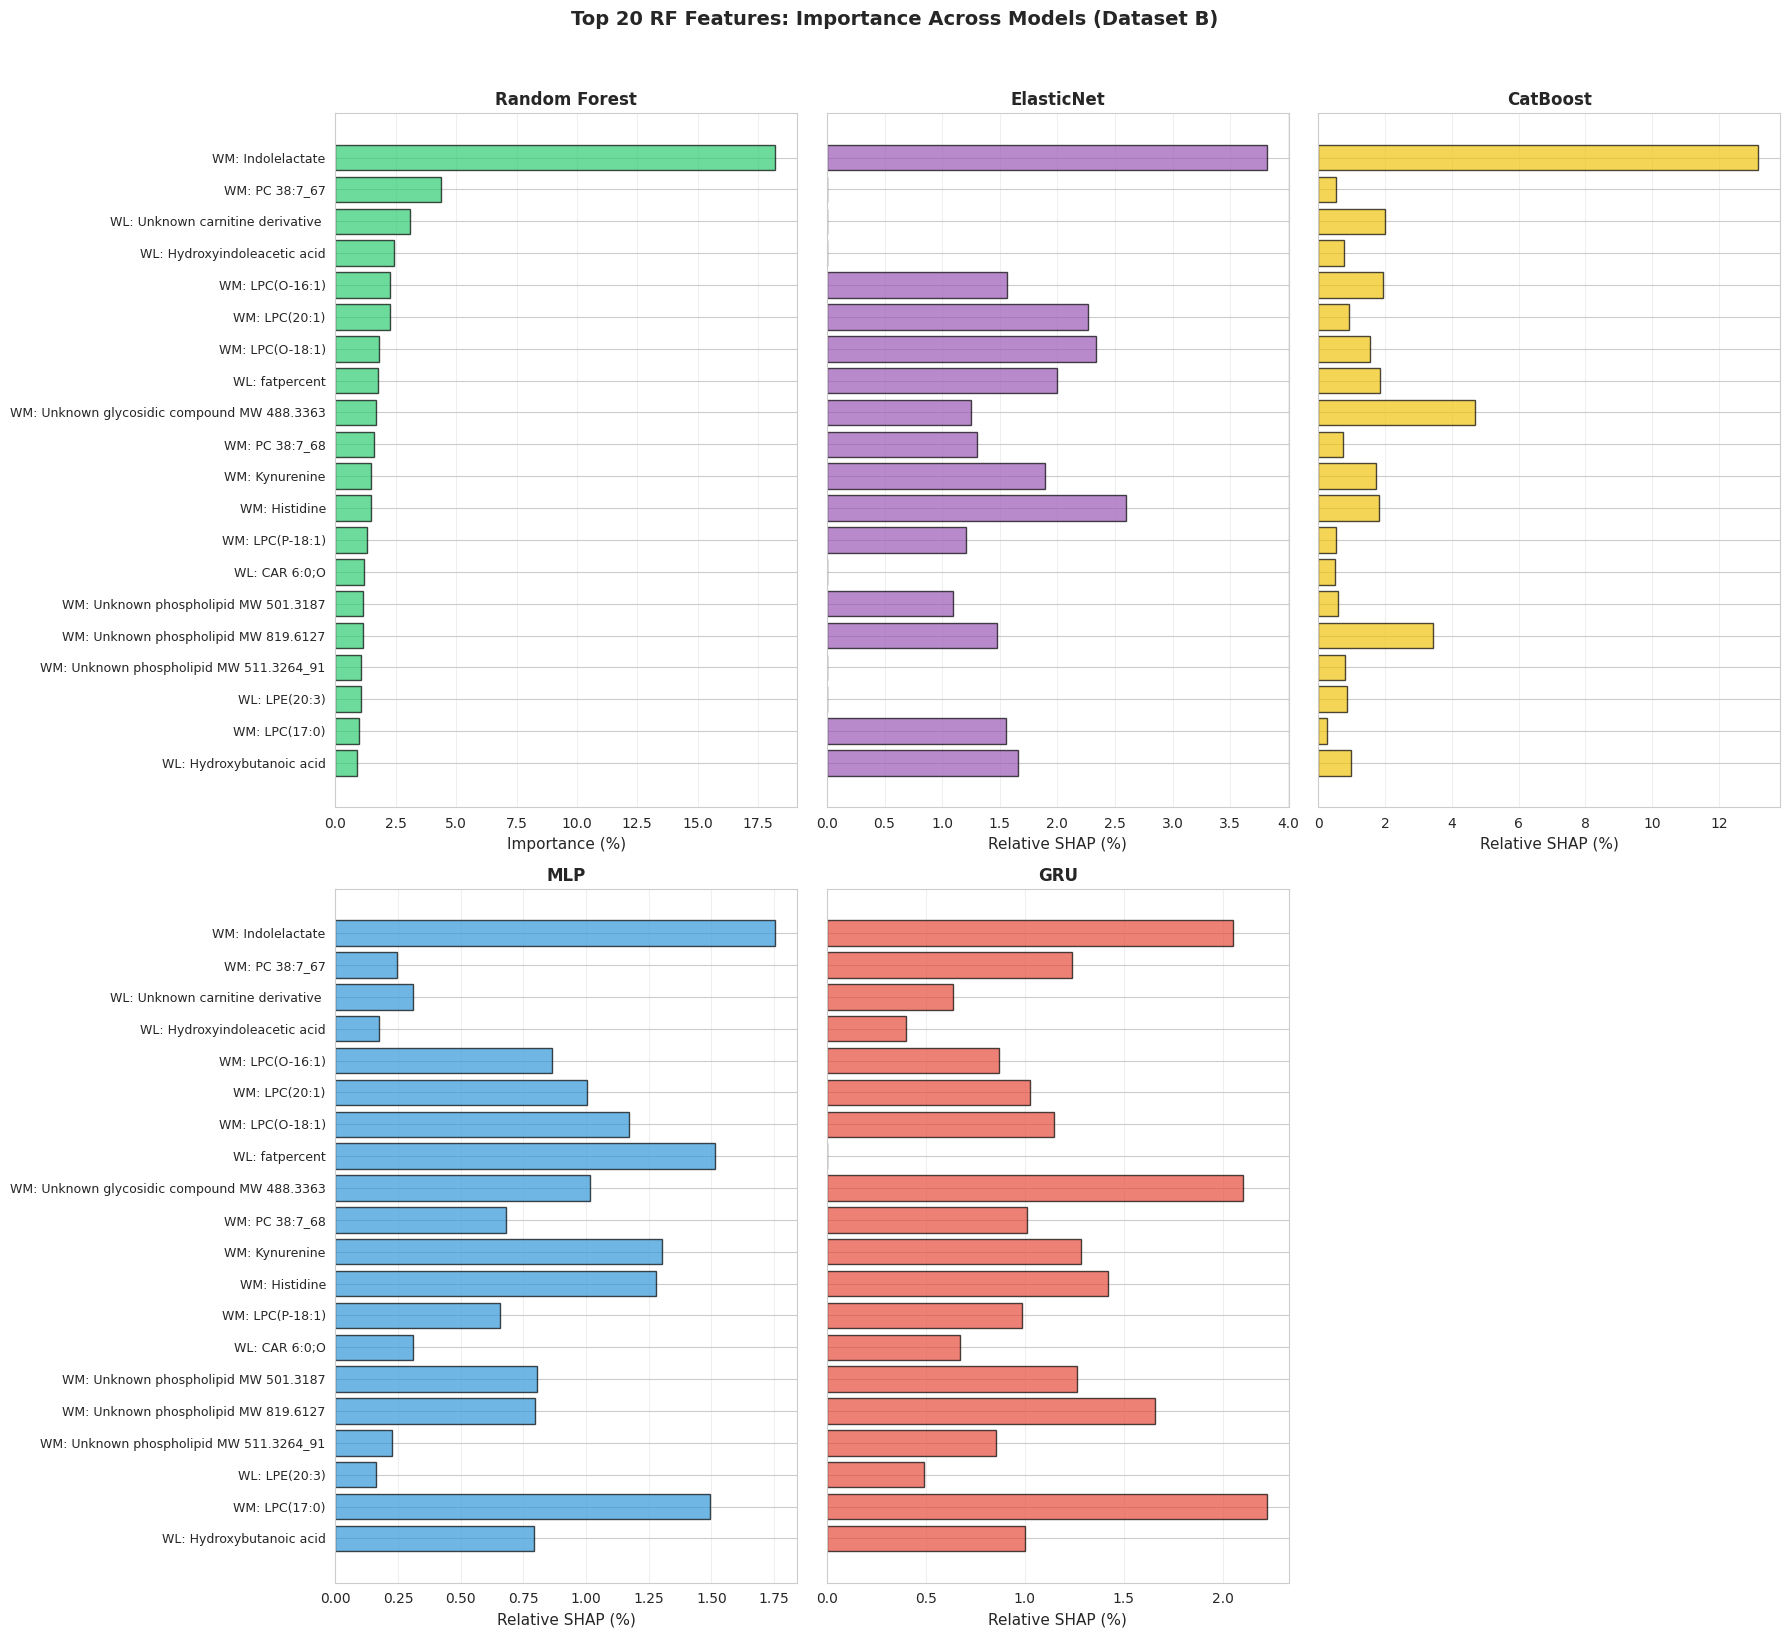

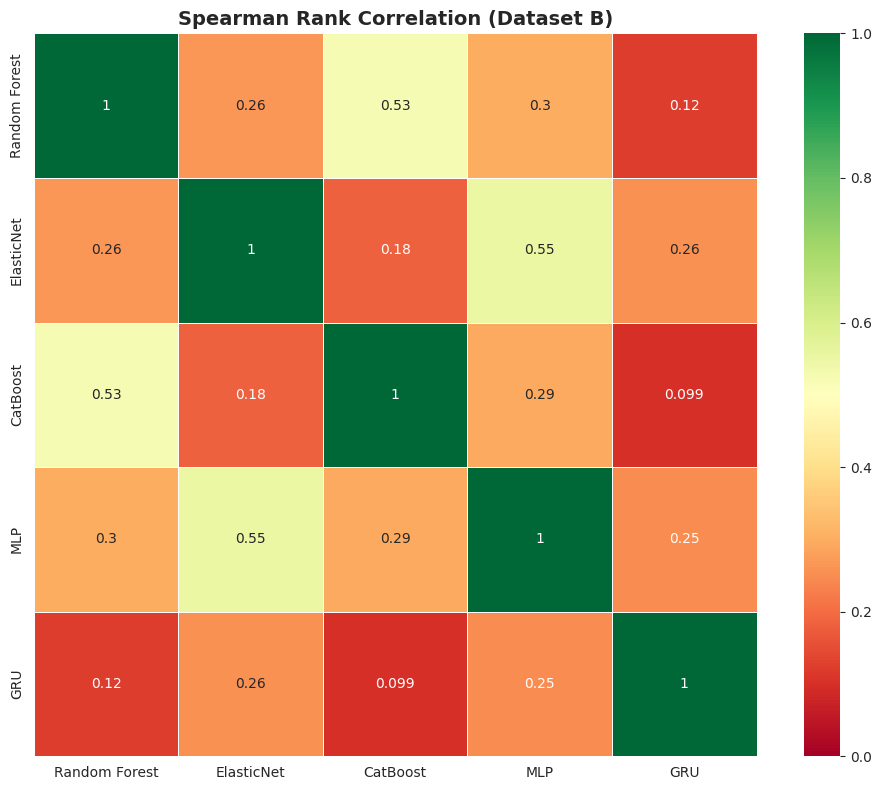

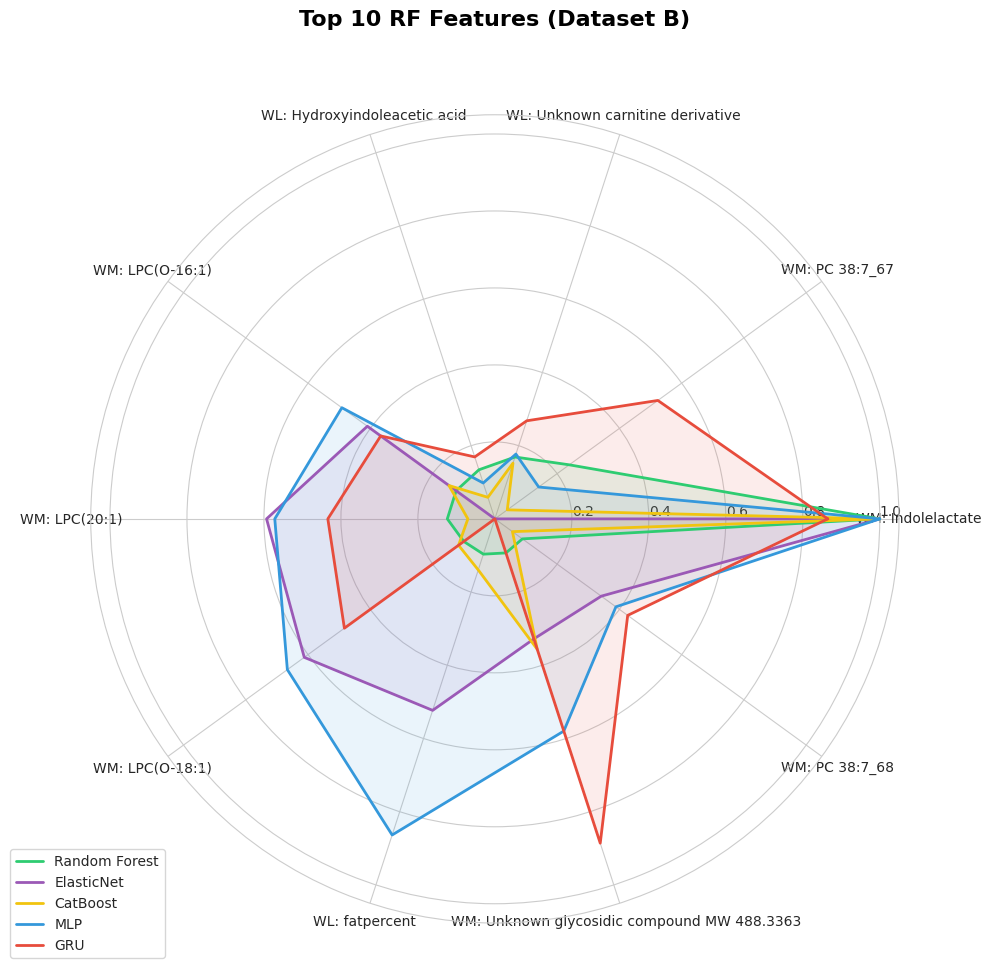

✅ SHAP analysis completed for Dataset B

Processing Dataset C

Dataset C: 31 samples, 205 features

Dataset C:
  Samples: 31
  Common features: 100
  Temporal shape: (31, 2, 100) (samples, timesteps, features)


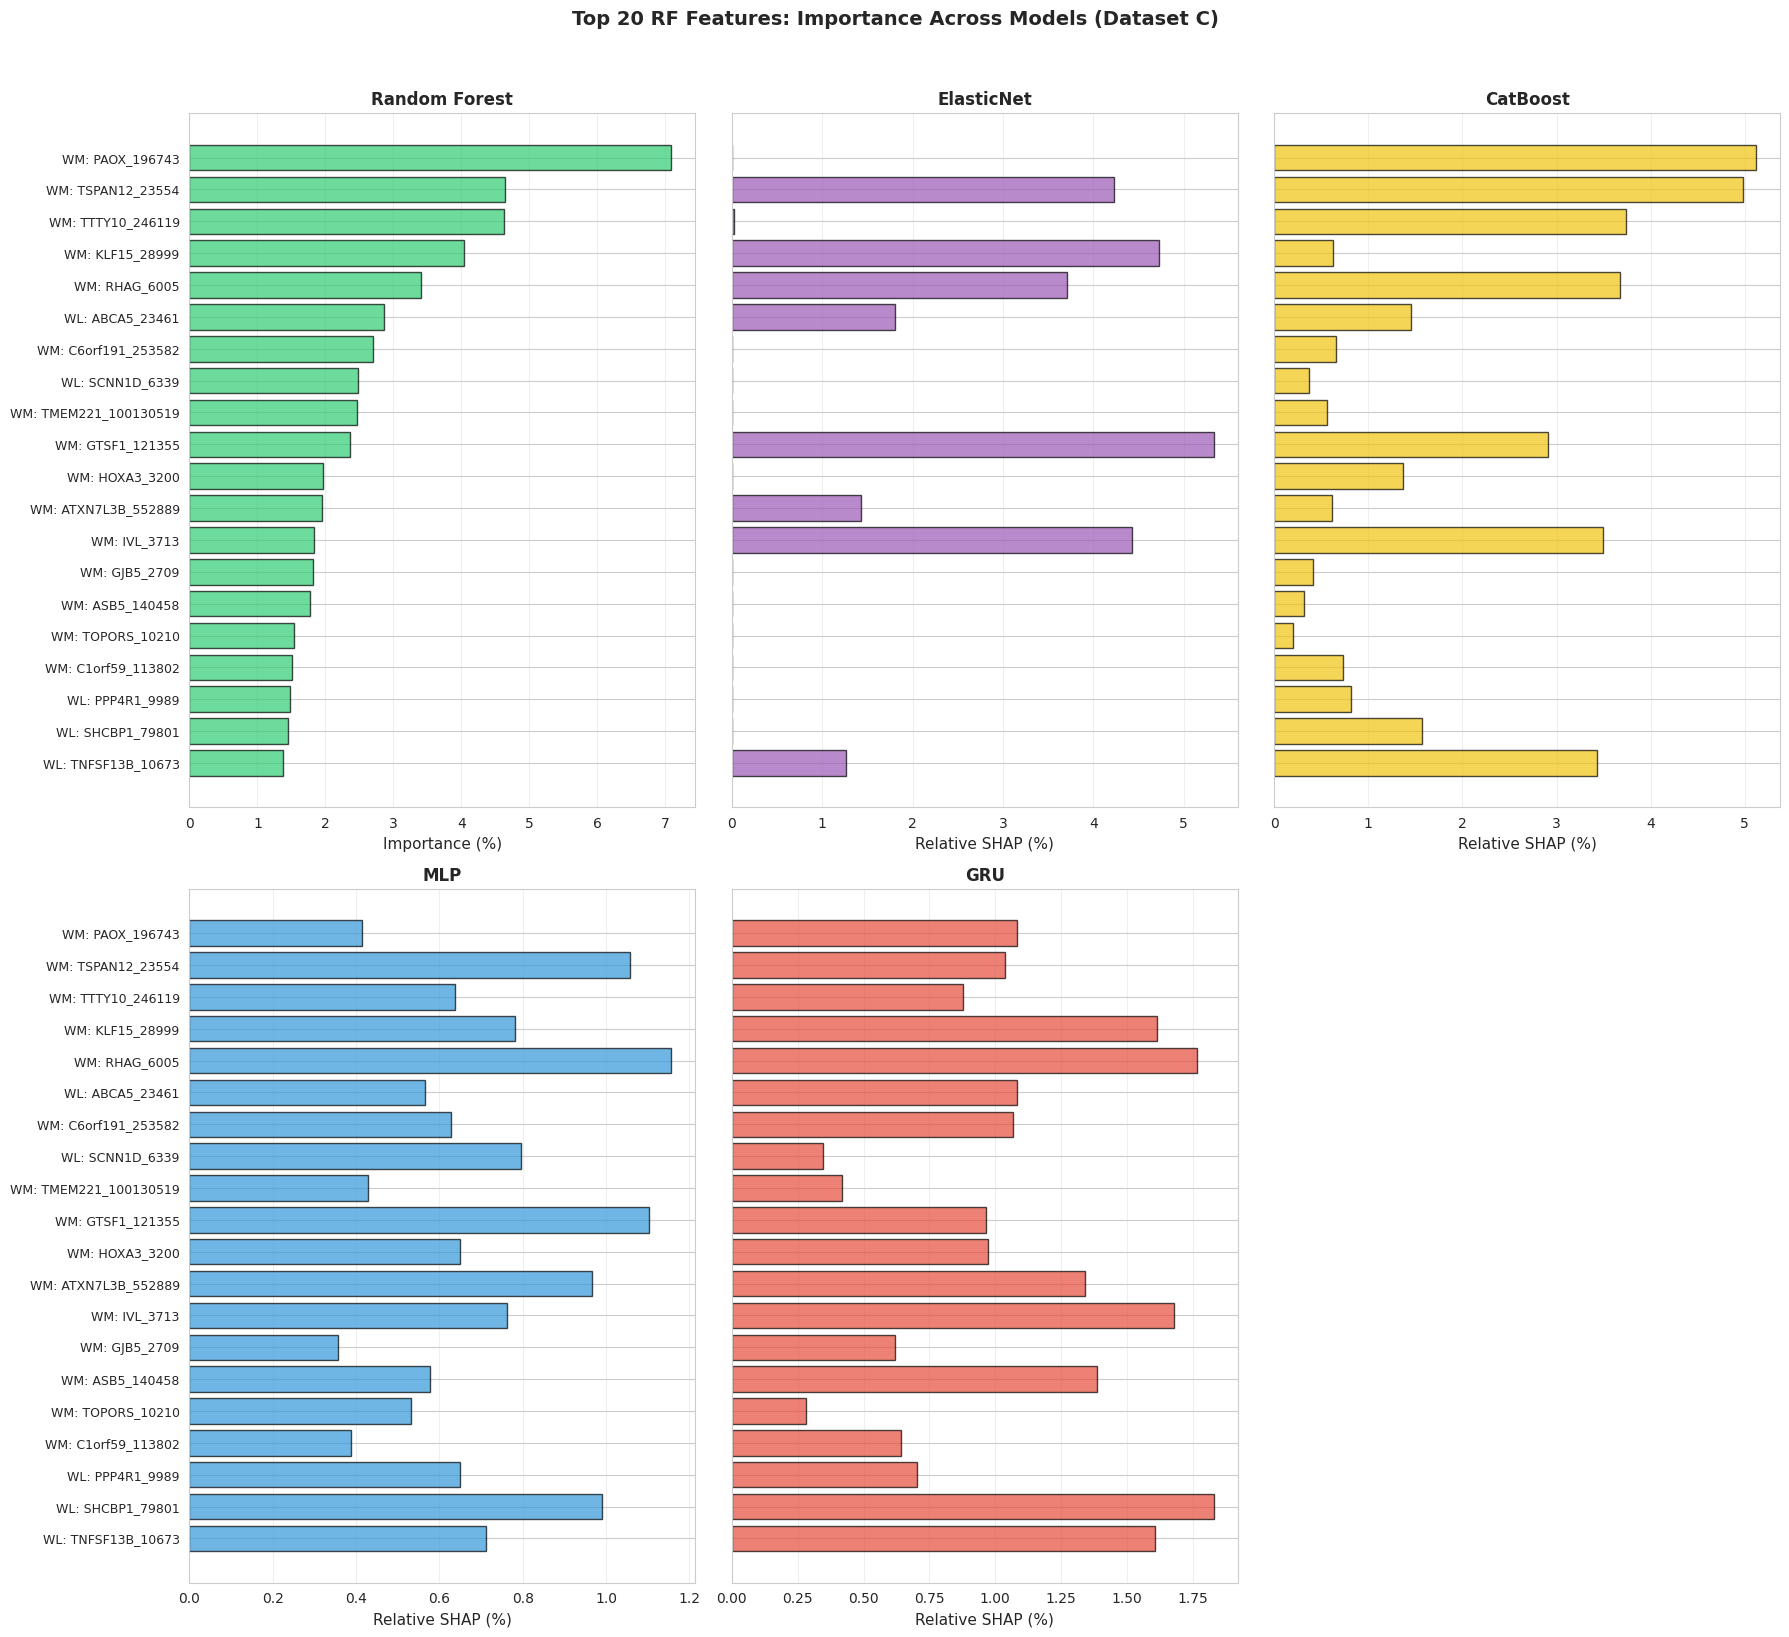

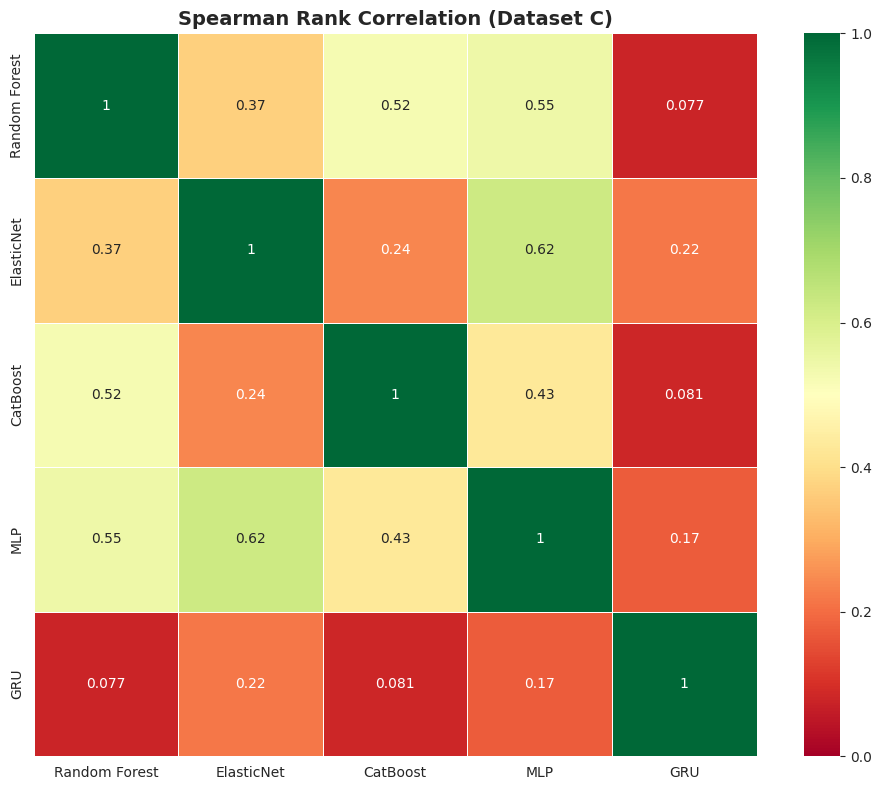

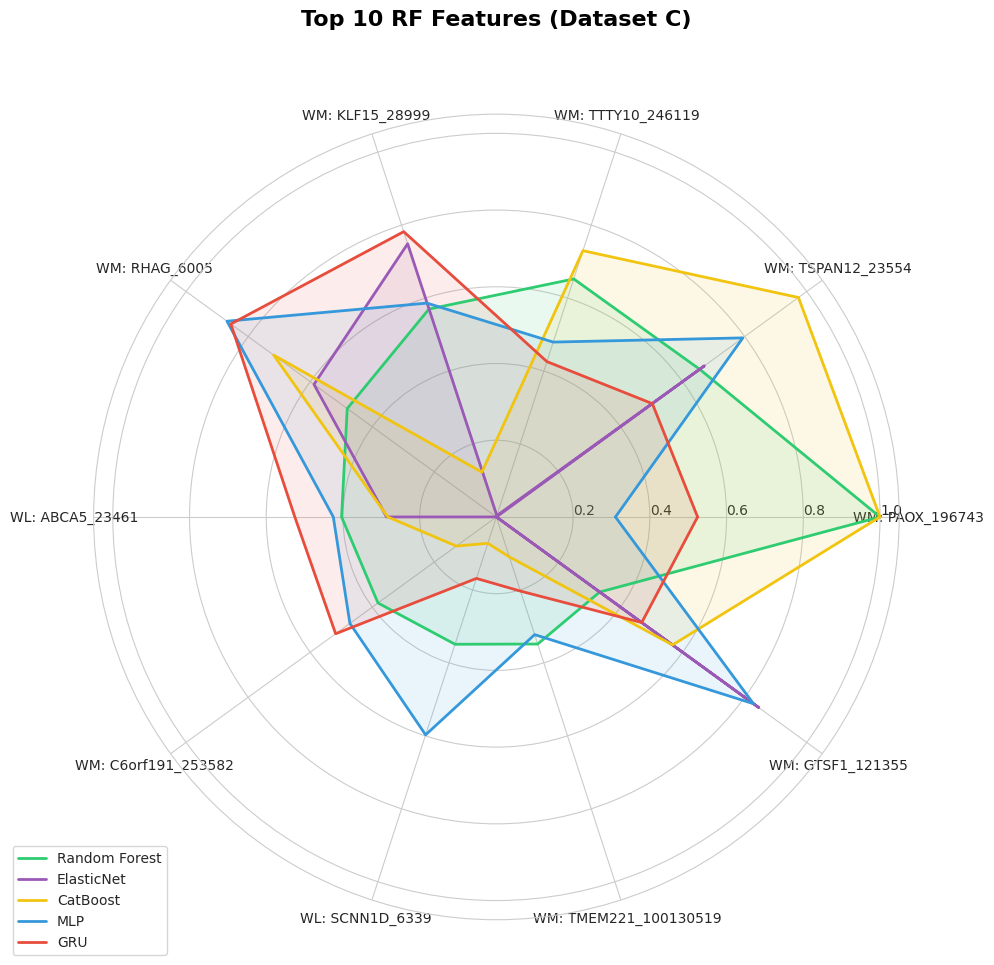

✅ SHAP analysis completed for Dataset C


In [2]:
DATASETS = {
    'B': 'dataset_B_metabolomics.csv',
    'C': 'dataset_C_transcriptomics.csv'
}

rf_results_all = pickle.load(open(RESULTS_DIR / 'rf_results.pkl', 'rb'))

for ds_suffix, ds_filename in DATASETS.items():
    print(f"\n{'='*40}\nProcessing Dataset {ds_suffix}\n{'='*40}")
    
    # Load data
    dataset = pd.read_csv(PROCESSED_DIR / ds_filename)
    
    # Prepare data for flat models (RF, MLP)
    X_flat, y, feature_names_flat = prepare_data(dataset, f"Dataset {ds_suffix}")
    
    # Prepare data for sequence models (GRU)
    X_temporal, y_temp, feature_names_temporal = prepare_lstm_data(dataset, f"Dataset {ds_suffix}")
    
    # Impute missing values globally for SHAP analysis
    imputer = SimpleImputer(strategy="mean", keep_empty_features=True)
    X_flat = imputer.fit_transform(X_flat)
    X_temp_reshaped = X_temporal.reshape(-1, X_temporal.shape[-1])
    X_temporal = imputer.fit_transform(X_temp_reshaped).reshape(X_temporal.shape)

    scaler = StandardScaler()
    X_flat_scaled = scaler.fit_transform(X_flat)
    
    # 1. Random Forest Feature Importance
    rf_importances = rf_results_all[f'dataset_{ds_suffix}']['feature_importances']
    rf_feature_names = rf_results_all[f'dataset_{ds_suffix}']['feature_names']
    rf_importance_mean = rf_importances.mean(axis=0) if rf_importances.ndim > 1 else rf_importances
    
    rf_importance_df = pd.DataFrame({
        'feature': rf_feature_names,
        'importance': rf_importance_mean,
        'model': 'Random Forest'
    }).sort_values('importance', ascending=False)
    rf_importance_df['importance'] = (rf_importance_df['importance'] / rf_importance_df['importance'].sum()) * 100
    
    # 1.1 ElasticNet SHAP Values
    en_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
    en_model.fit(X_flat_scaled, y)
    explainer_en = shap.LinearExplainer(en_model, X_flat_scaled)
    shap_values_en = explainer_en.shap_values(X_flat_scaled)
    en_importance = np.abs(shap_values_en).mean(axis=0)
    en_importance_df = pd.DataFrame({
        'feature': feature_names_flat,
        'importance': en_importance,
        'model': 'ElasticNet'
    }).sort_values('importance', ascending=False)
    en_importance_df['importance'] = (en_importance_df['importance'] / en_importance_df['importance'].sum()) * 100

    # 1.2 CatBoost SHAP Values
    cb_model = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=False, random_seed=42)
    cb_model.fit(X_flat_scaled, y)
    explainer_cb = shap.TreeExplainer(cb_model)
    shap_values_cb = explainer_cb.shap_values(X_flat_scaled)
    cb_importance = np.abs(shap_values_cb).mean(axis=0)
    cb_importance_df = pd.DataFrame({
        'feature': feature_names_flat,
        'importance': cb_importance,
        'model': 'CatBoost'
    }).sort_values('importance', ascending=False)
    cb_importance_df['importance'] = (cb_importance_df['importance'] / cb_importance_df['importance'].sum()) * 100

    # 2. MLP SHAP Values
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_tensor = torch.FloatTensor(X_flat_scaled).to(device)
    y_tensor = torch.FloatTensor(y).to(device)
    mlp_model = MLP(input_dim=X_flat.shape[1], hidden_dims=[128, 64, 32], dropout=0.3).to(device)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)
    
    mlp_model.train()
    for epoch in range(200):
        optimizer.zero_grad()
        outputs = mlp_model(X_tensor)
        loss = criterion(outputs, y_tensor.view(-1, 1))
        loss.backward()
        optimizer.step()
    mlp_model.eval()
    
    background = X_tensor[:min(100, len(X_tensor))]
    explainer_mlp = shap.DeepExplainer(mlp_model, background)
    shap_values_mlp = explainer_mlp.shap_values(X_tensor)
    mlp_importance = np.abs(shap_values_mlp).mean(axis=0)
    mlp_importance = np.asarray(mlp_importance).squeeze()
    mlp_importance_df = pd.DataFrame({
        "feature": feature_names_flat,
        "importance": mlp_importance,
        "model": "MLP",
    }).sort_values("importance", ascending=False)
    mlp_importance_df['importance'] = (mlp_importance_df['importance'] / mlp_importance_df['importance'].sum()) * 100

    # 3. GRU SHAP Values
    scaler_gru = StandardScaler()
    X_temporal_reshaped = X_temporal.reshape(-1, X_temporal.shape[-1])
    X_temporal_scaled = scaler_gru.fit_transform(X_temporal_reshaped).reshape(X_temporal.shape)
    
    X_gru_tensor = torch.FloatTensor(X_temporal_scaled).to(device)
    y_gru_tensor = torch.FloatTensor(y_temp).to(device)
    gru_model = GRUModel(input_dim=X_temporal.shape[2], hidden_dim=64, num_layers=1, dropout=0.4).to(device)
    optimizer_gru = torch.optim.Adam(gru_model.parameters(), lr=0.001)
    
    gru_model.train()
    for epoch in range(350):
        optimizer_gru.zero_grad()
        outputs = gru_model(X_gru_tensor)
        loss = criterion(outputs, y_gru_tensor.view(-1, 1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gru_model.parameters(), max_norm=1.0)
        optimizer_gru.step()
    gru_model.eval()
    
    background_gru = X_gru_tensor[:min(100, len(X_gru_tensor))]
    explainer_gru = shap.GradientExplainer(gru_model, background_gru)
    with torch.backends.cudnn.flags(enabled=False):
        shap_values_gru = explainer_gru.shap_values(X_gru_tensor)
    if isinstance(shap_values_gru, list):
        shap_values_gru = shap_values_gru[0]
    gru_importance = np.abs(shap_values_gru).mean(axis=(0, 1))
    gru_importance = np.asarray(gru_importance).squeeze()
    gru_importance_df = pd.DataFrame({
        'feature': feature_names_temporal,
        'importance': gru_importance,
        'model': 'GRU'
    }).sort_values('importance', ascending=False)
    gru_importance_df['importance'] = (gru_importance_df['importance'] / gru_importance_df['importance'].sum()) * 100

    # 4. Save results
    rf_importance_df.to_csv(RESULTS_DIR / f'shap_rf_importance_{ds_suffix}.csv', index=False)
    en_importance_df.to_csv(RESULTS_DIR / f'shap_en_importance_{ds_suffix}.csv', index=False)
    cb_importance_df.to_csv(RESULTS_DIR / f'shap_cb_importance_{ds_suffix}.csv', index=False)
    mlp_importance_df.to_csv(RESULTS_DIR / f'shap_mlp_importance_{ds_suffix}.csv', index=False)
    gru_importance_df.to_csv(RESULTS_DIR / f'shap_gru_importance_{ds_suffix}.csv', index=False)
    
    # 5. Combined top 20 comparison
    comparison_data = []
    for i, feat in enumerate(rf_importance_df.head(20)['feature']):
        row = {'rank': i+1, 'feature': feat, 'rf_importance': rf_importance_df[rf_importance_df['feature'] == feat]['importance'].values[0]}
        for m_name, m_df in [('en', en_importance_df), ('cb', cb_importance_df), ('mlp', mlp_importance_df)]:
            if feat in m_df['feature'].values:
                row[f'{m_name}_importance'] = m_df[m_df['feature'] == feat]['importance'].values[0]
            else:
                row[f'{m_name}_importance'] = 0
        
        feat_base = feat.replace('WL_vel_', '').replace('WM_vel_', '')
        if feat_base in gru_importance_df['feature'].values:
            row['gru_importance'] = gru_importance_df[gru_importance_df['feature'] == feat_base]['importance'].values[0]
        else:
            row['gru_importance'] = 0
        comparison_data.append(row)
    pd.DataFrame(comparison_data).to_csv(RESULTS_DIR / f'shap_top20_comparison_{ds_suffix}.csv', index=False)

    # 6. Visualizations
    TOP_N = 20
    rf_top_ordered = rf_importance_df.head(TOP_N)['feature'].tolist()
    feature_labels = [f.replace('WL_vel_', 'WL: ').replace('WM_vel_', 'WM: ') for f in rf_top_ordered]
    
    def importance_for_features(importance_df, features):
        importance_lookup = importance_df.set_index('feature')['importance']
        return [importance_lookup.get(f, 0) for f in features]

    rf_vals = importance_for_features(rf_importance_df, rf_top_ordered)
    en_vals = importance_for_features(en_importance_df, rf_top_ordered)
    cb_vals = importance_for_features(cb_importance_df, rf_top_ordered)
    mlp_vals = importance_for_features(mlp_importance_df, rf_top_ordered)
    gru_importance_lookup = gru_importance_df.set_index('feature')['importance']
    gru_vals = [gru_importance_lookup.get(f.replace('WL_vel_', '').replace('WM_vel_', ''), 0) for f in rf_top_ordered]

    fig, axes = plt.subplots(2, 3, figsize=(18, 16), sharey=True)
    axes = axes.flatten()
    model_plots = [
        ('Random Forest', 'Importance (%)', rf_vals, '#2ecc71'),
        ('ElasticNet', 'Relative SHAP (%)', en_vals, '#9b59b6'),
        ('CatBoost', 'Relative SHAP (%)', cb_vals, '#f1c40f'),
        ('MLP', 'Relative SHAP (%)', mlp_vals, '#3498db'),
        ('GRU', 'Relative SHAP (%)', gru_vals, '#e74c3c'),
    ]
    for ax, (title, xlabel, vals, color) in zip(axes, model_plots):
        ax.barh(range(TOP_N), vals, color=color, alpha=0.7, edgecolor='black')
        ax.set_yticks(range(TOP_N))
        ax.set_yticklabels(feature_labels, fontsize=9)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
    if len(model_plots) < len(axes): axes[-1].set_visible(False)
    plt.suptitle(f'Top {TOP_N} RF Features: Importance Across Models (Dataset {ds_suffix})', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'shap_comparison_topn_{ds_suffix}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Correlation Matrix
    all_importances = pd.DataFrame({
        'Random Forest': rf_importance_df.set_index('feature')['importance'],
        'ElasticNet': en_importance_df.set_index('feature')['importance'],
        'CatBoost': cb_importance_df.set_index('feature')['importance'],
        'MLP': mlp_importance_df.set_index('feature')['importance']
    })
    gru_mapped = {feat: gru_importance_lookup.get(feat.replace('WL_vel_', '').replace('WM_vel_', ''), 0) for feat in rf_feature_names}
    all_importances['GRU'] = pd.Series(gru_mapped)
    corr_matrix = all_importances.corr(method='spearman')
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5, square=True, linewidths=.5)
    plt.title(f'Spearman Rank Correlation (Dataset {ds_suffix})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'shap_importance_correlation_{ds_suffix}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Spider plots
    models_info = [('Random Forest', rf_importance_df), ('ElasticNet', en_importance_df), ('CatBoost', cb_importance_df), ('MLP', mlp_importance_df), ('GRU', gru_importance_df)]
    dfs = {name: df for name, df in models_info}
    TOP_N_SPIDER = 10
    rf_top_features_spider = dfs['Random Forest'].head(TOP_N_SPIDER)['feature'].tolist()
    clean_labels_spider = [f.replace('WL_vel_', 'WL: ').replace('WM_vel_', 'WM: ') for f in rf_top_features_spider]
    comparison_data_spider = {}
    for name, df in dfs.items():
        importance_lookup = df.set_index('feature')['importance']
        max_imp = importance_lookup.max()
        if max_imp > 0: importance_lookup = importance_lookup / max_imp
        if name == 'GRU':
            vals = [importance_lookup.get(f.replace('WL_vel_', '').replace('WM_vel_', ''), 0) for f in rf_top_features_spider]
        else:
            vals = [importance_lookup.get(f, 0) for f in rf_top_features_spider]
        comparison_data_spider[name] = vals
    create_spider_plot(comparison_data_spider, clean_labels_spider, f'Top {TOP_N_SPIDER} RF Features (Dataset {ds_suffix})', RESULTS_DIR / f'shap_spider_comparison_{ds_suffix}.png')

    print(f"✅ SHAP analysis completed for Dataset {ds_suffix}")

